In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import time

In [3]:
# Basic OpenF1 API interaction to get season results
BASE_URL = "https://api.openf1.org/v1"
def get_season_results(season: int) -> pd.DataFrame:
    url = f"{BASE_URL}/sessions"
    params = {
        "year": season
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)

In [4]:
# Example usage
df = get_season_results(2023)
session_keys = df["session_key"].unique()
df.head()

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,9222,Practice,Day 1,2023-02-23T07:00:00+00:00,2023-02-23T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
1,7763,Practice,Day 2,2023-02-24T07:00:00+00:00,2023-02-24T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
2,7764,Practice,Day 3,2023-02-25T07:00:00+00:00,2023-02-25T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
3,7765,Practice,Practice 1,2023-03-03T11:30:00+00:00,2023-03-03T12:30:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
4,7766,Practice,Practice 2,2023-03-03T15:00:00+00:00,2023-03-03T16:00:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023


In [ ]:
# Get session results
def get_session_results(session_id: int) -> pd.DataFrame:
    url = f"{BASE_URL}/session_result"
    params = {
        "session_key": session_id
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)
# Get session laps
def get_session_laps(session_id: int) -> pd.DataFrame:
    url = f"{BASE_URL}/laps"
    params = {
        "session_key": session_id
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)

In [ ]:
# Stack all session results for the season
for session_key in session_keys[:15]: # limit to first 30 requests (15 sessions) for testing
    df_session_results = get_session_results(session_key)
    df_session_laps = get_session_laps(session_key)
    # important: stay under the minute cap
    time.sleep(1)
    if "df_results" in locals():
        df_results = pd.concat([df_results, df_session_results], ignore_index=True)
        df_laps = pd.concat([df_laps, df_session_laps], ignore_index=True)
    else:
        df_results = df_session_results
        df_laps = df_session_laps
print(df_results.shape)
df_results.head()

(1802, 11)


,position,driver_number,number_of_laps,dnf,dns,dsq,duration,gap_to_leader,meeting_key,session_key,points
0,1.0,1,24,False,False,False,77.565,0.0,1143,7782,NaN
1,2.0,14,26,False,False,False,77.727,0.162,1143,7782,NaN
2,3.0,31,23,False,False,False,77.938,0.373,1143,7782,NaN
3,4.0,63,23,False,False,False,77.955,0.39,1143,7782,NaN
4,5.0,10,23,False,False,False,78.094,0.529,1143,7782,NaN


In [16]:
print(df_laps.shape)
df_laps.head()

(56541, 16)


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1143,7782,18,1,None,NaN,19.248,NaN,264.0,300.0,True,NaN,"[2064, 2049, 2051, 2049, 2051, 2051, 2051, 205...","[2051, 2051, 2051, 2051, 2051]",[2051],188.0
1,1143,7782,14,1,2023-04-01T01:30:29.596000+00:00,38.550,19.922,NaN,263.0,295.0,True,472.688,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2064, 2064]",203.0
2,1143,7782,55,1,2023-04-01T01:30:47.892000+00:00,39.496,19.811,39.058,249.0,279.0,True,98.365,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2051]",175.0
3,1143,7782,27,1,2023-04-01T01:30:51.001000+00:00,40.087,19.693,37.503,240.0,272.0,True,97.283,"[2064, 2051, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 2049]",212.0
4,1143,7782,16,1,2023-04-01T01:31:01.251000+00:00,42.209,21.563,42.750,240.0,253.0,True,106.522,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]",201.0


   session_key  driver_number     avg_lap  best_lap  consistency  position
0         7763              1  247.173304    91.650   366.636978       2.0
1         7763              1  247.173304    91.650   366.636978       2.0
2         7763              1  247.173304    91.650   366.636978       2.0
3         7763              1  247.173304    91.650   366.636978       2.0
4         7763              2  192.072113    92.549   327.229136       7.0
(1802, 6)


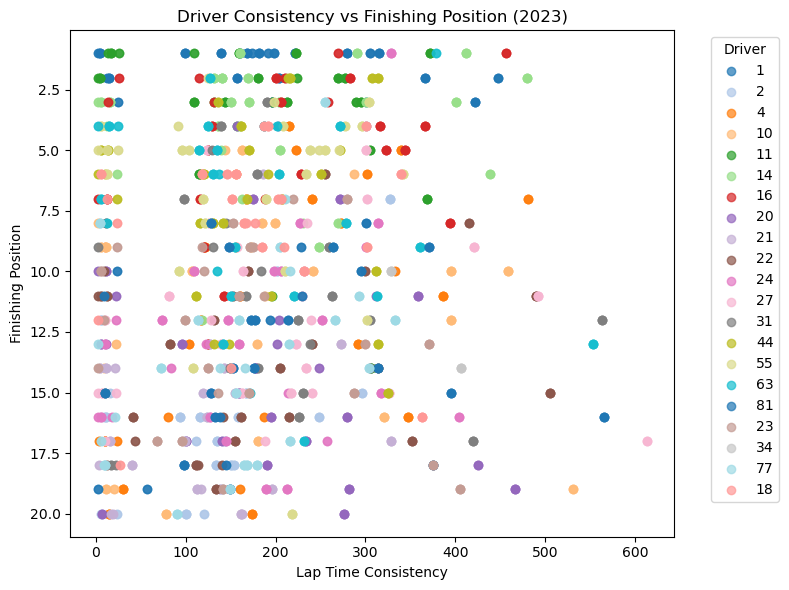

In [ ]:
# Analyze lap times by driver/session_key 
driver_stats = df_laps.groupby(
    ["session_key", "driver_number"]
    ).agg(
    avg_lap=("lap_duration", "mean"),
    best_lap=("lap_duration", "min"),
    consistency=("lap_duration", "std")
    ).reset_index()
new_df = driver_stats.merge(
    df_results[["session_key","driver_number","position"]],
    on=["session_key","driver_number"],
    how="left"
)
print(new_df.head())
print(new_df.shape)

# Plot consistency vs position
drivers = new_df["driver_number"].unique()

driver_colors = {
    d: plt.cm.tab20(i % 20) 
    for i, d in enumerate(sorted(drivers))
}
plt.figure(figsize=(8,6))
for driver in drivers:
    
    d = new_df[new_df["driver_number"] == driver]
    
    plt.scatter(
        d["consistency"],
        d["position"],
        color=driver_colors[driver],
        label=str(driver),
        alpha=0.7
    )
plt.xlabel("Lap Time Consistency")
plt.ylabel("Finishing Position")
plt.title("Driver Consistency vs Finishing Position (2023)")
plt.gca().invert_yaxis()

plt.legend(title="Driver", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

   driver_number  avg_consistency  avg_position
0              1       207.683164      2.397727
1              2       127.838042     16.012821
2              4       182.927783     11.923913
3             10       184.625667     10.956522
4             11       185.299636      3.376471
(21, 3)


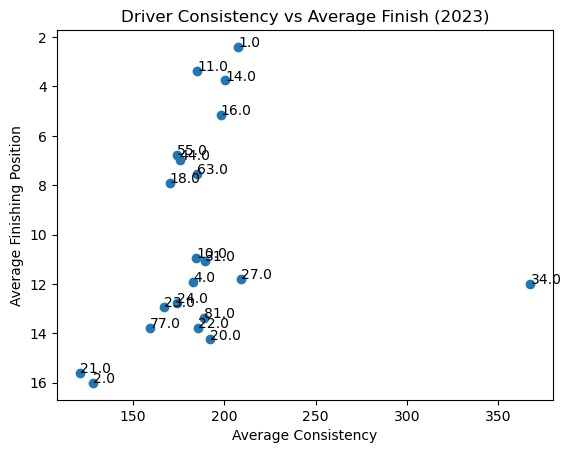

In [29]:
# Average consistency vs average position by driver for better visualization
season_stats = new_df.groupby("driver_number").agg(
    avg_consistency=("consistency","mean"),
    avg_position=("position","mean")
).reset_index()

print(season_stats.head())
print(season_stats.shape)

plt.scatter(
    season_stats["avg_consistency"],
    season_stats["avg_position"]
)

for _,row in season_stats.iterrows():
    plt.text(
        row["avg_consistency"],
        row["avg_position"],
        str(row["driver_number"])
    )

plt.gca().invert_yaxis()
plt.xlabel("Average Consistency")
plt.ylabel("Average Finishing Position")
plt.title("Driver Consistency vs Average Finish (2023)")
plt.show()

   driver_number  best_lap  avg_position
0              1    76.732      2.397727
1              2    78.557     16.012821
2              4    78.119     11.923913
3             10    77.574     10.956522
4             11    78.123      3.376471
(21, 3)


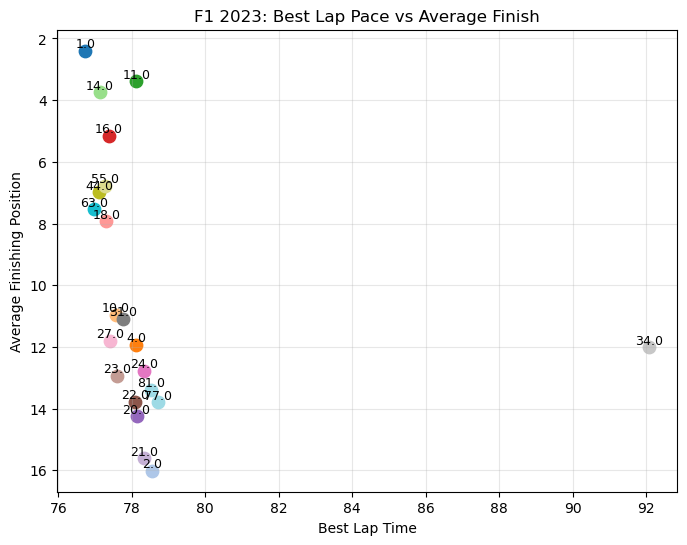

In [30]:
# Average best lap vs average position by driver for better visualization
season_stats = new_df.groupby("driver_number").agg(
    best_lap=("best_lap","min"),
    avg_position=("position","mean")
).reset_index()

print(season_stats.head())
print(season_stats.shape)

drivers = season_stats["driver_number"].unique()

colors = plt.cm.tab20(np.linspace(0,1,len(drivers)))
color_map = dict(zip(drivers, colors))

plt.figure(figsize=(8,6))

for _, row in season_stats.iterrows():

    plt.scatter(
        row["best_lap"],
        row["avg_position"],
        color=color_map[row["driver_number"]],
        s=80
    )

    plt.text(
        row["best_lap"],
        row["avg_position"],
        str(row["driver_number"]),
        fontsize=9,
        ha="center",
        va="bottom"
    )

plt.xlabel("Best Lap Time")
plt.ylabel("Average Finishing Position")
plt.title("F1 2023: Best Lap Pace vs Average Finish")

plt.gca().invert_yaxis()
plt.grid(alpha=0.3)

plt.show()